In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score

# Titanic Survival Classification — Model Development & Selection

This project uses the Seaborn **Titanic** dataset (891 records) to build and compare binary classification models predicting passenger survival. The pipeline covers exploratory data analysis, data preparation, stratified imputation, baseline model training, hyperparameter tuning, and champion model selection.

---

## Pipeline Overview

**1. Exploratory Data Analysis**
Investigated missing values (age: 19.9%, deck: 77.2%), four pairs of redundant features, and the engineered feature `adult_male` (derived from `sex` and `age >= 16`). Explored survival counts and rates by sex and passenger class, age distributions, and median age by class. Identified four categorical features (`pclass`, `sex`, `embarked`, `alone`) from a mix of integer, boolean, and object data types.

**2. Data Preparation**
- Dropped `deck` (>75% missing) and all redundant/engineered features (`alive`, `class`, `embark_town`, `who`, `adult_male`)
- Removed two rows with missing `embarked` values (889 rows retained)
- Split into training (80%) and testing (20%) sets with `stratify=y` to preserve the ~38% survival rate across all partitions
- Imputed missing `age` values using median age per passenger class, computed from training data only to prevent data leakage
- Encoded categorical features via `OneHotEncoder(drop="first")` and standardized numerical features via `StandardScaler` using `ColumnTransformer`

**3. Initial Model Training**
Evaluated three classifiers — `SVC(probability=True, random_state=415)`, `LogisticRegression(max_iter=100000)`, and `DecisionTreeClassifier(random_state=415)` — using 5-fold `cross_val_predict`. Presented confusion matrices, classification reports, ROC-AUC scores, and predicted probability distributions for each default model. 

**4. Hyperparameter Tuning**
Applied `GridSearchCV` (5-fold, accuracy scoring) to identify optimal configurations for each classifier:
- **SVC** — RBF kernel only; searched `C` (0.001–100) and `gamma` (0.001–10) across 2,500 combinations
- **Logistic Regressor** — searched L1/L2 penalty and `C` (0.001–1000) via `liblinear` solver
- **Decision Tree** — searched `max_depth` and `min_samples_leaf` across 400 combinations (1–20 each)
All optimal hyperparameters were verified to lie within the interior of their respective search ranges.

**5. Model Selection**
Re-evaluated all three tuned classifiers using `cross_val_predict(best_estimator_, ...)`. Compared tuned vs. untuned confusion matrices, classification reports, and ROC-AUC scores. The **tuned SVC** (C≈49.4, γ≈0.030) emerged as the champion model (~84.8% CV accuracy, highest class-1 recall at 0.74), reflecting its ability to find a maximum-margin decision boundary in the transformed feature space.

# Exploratory Data Analysis

## Part 1(a) - Load dataset

![alt text](titanic_dataset_appendix-1.png)

In [25]:
df = sns.load_dataset('titanic') # target_variable = 'survived'
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


## Part 1(b) - Data Set Dimensions

In [26]:
print(f'The titanic dataset has {df.shape[0]} rows and {df.shape[1]} columns.\n')
print(f"For this classification model, the target variable will be 'survived.'")

The titanic dataset has 891 rows and 15 columns.

For this classification model, the target variable will be 'survived.'


## Part 1(c) - Missing Values

In [27]:
print(f'-----[Missing / Null Values]-----')
print(f'__________________________________')
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'count':df.isnull().sum(), 'pct':missing_pct})

-----[Missing / Null Values]-----
__________________________________


,count,pct
survived,0,0.00
pclass,0,0.00
sex,0,0.00
age,177,19.87
sibsp,0,0.00
parch,0,0.00
fare,0,0.00
embarked,2,0.22
class,0,0.00
who,0,0.00


## Dataset Descriptive Statistics

In [28]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## Part 1(d) - Redundant Features

In [29]:
redundancy_pairs = [['alive', 'survived'], ['pclass', 'class'], ['embarked', 'embark_town'], ['adult_male', 'who']]

for pair in redundancy_pairs:
    print(f'Checking redundancy for {pair}')
    display(df[pair].drop_duplicates())

Checking redundancy for ['alive', 'survived']


,alive,survived
0,no,0
1,yes,1


Checking redundancy for ['pclass', 'class']


,pclass,class
0,3,Third
1,1,First
9,2,Second


Checking redundancy for ['embarked', 'embark_town']


,embarked,embark_town
0,S,Southampton
1,C,Cherbourg
5,Q,Queenstown
61,NaN,NaN


Checking redundancy for ['adult_male', 'who']


,adult_male,who
0,True,man
1,False,woman
7,False,child


## Part 1(e) - Engineered Features

In [30]:
adult_male_group = df.groupby(['adult_male', 'sex'])['age'].agg(['min', 'median', 'max'])
adult_male_group


min  median   max
adult_male sex                        
False      female   0.75    27.0  63.0
           male     0.42     4.0  15.0
True       male    16.00    30.0  80.0

As shown in the table above, 'adult_male' is engineered from 'sex' and 'age'. If the 'sex' value == 'male' and the 'age' value >= 16, then 'adult_male' == True...else, False.

## Part 1(f) - Exploration 

,total,died,pct_died
sex,,,
male,577,468,81.1
female,314,81,25.8


 ==[Survival percentages by class]== 
The survival rate in class 1 was 63.0%.
The survival rate in class 2 was 47.3%.
The survival rate in class 3 was 24.2%.

 =====[Median age by class]=====
The median age in class 1 was 37.0.
The median age in class 2 was 29.0.
The median age in class 3 was 24.0.


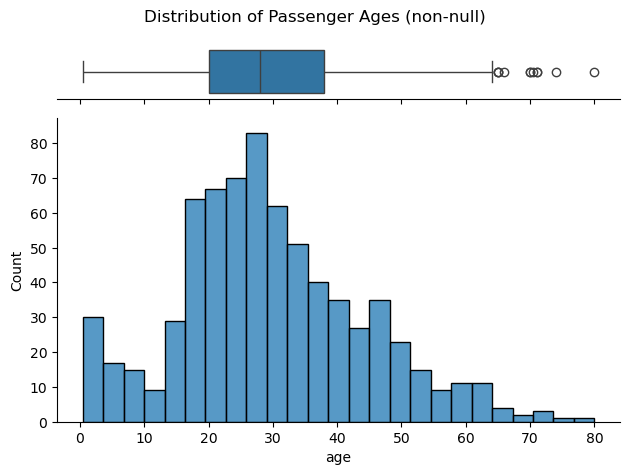

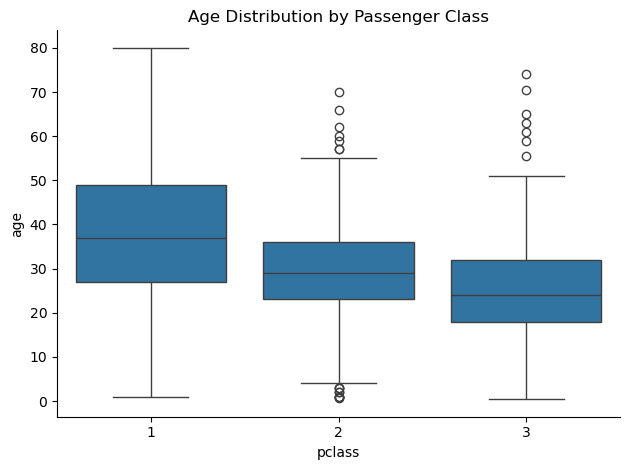

,survived,who,sex,count,pct_by_sex
0,0,child,female,15,34.88
1,0,child,male,19,47.50
2,0,man,male,449,83.61
3,0,woman,female,66,24.35
4,1,child,female,28,65.12
5,1,child,male,21,52.50
6,1,man,male,88,16.39
7,1,woman,female,205,75.65


In [31]:
survivor_conditions = ['survived', 'who', 'sex'] 

def exploration_section(dataframe):
    '''Outlines exploratory statistics for this dataset'''
    
    total_by_sex = dataframe['sex'].value_counts() # total passengers by sex

    died_by_sex = dataframe[dataframe['survived'] == 0]['sex'].value_counts() # passengers who died by sex

    pct_died = (died_by_sex / total_by_sex * 100).round(1) # percentage of each sex who died

    # exploration of survival data
    survivors_count = dataframe.groupby(survivor_conditions).size().reset_index(name='count') # returns GroupBy object of survivors for analysis of mortality-rate
    
    survivors_count['pct_by_sex'] = round((survivors_count['count'] / survivors_count.groupby(['who', 'sex'])['count'].transform('sum')) * 100, 2)
    
    survivors_by_pclass = dataframe.groupby('pclass')['survived'].mean() # survival percentage by class
    pclass_median_ages = dataframe.groupby('pclass')['age'].median() # median age per class

    mortality_count_df = pd.DataFrame({'total': total_by_sex, 'died': died_by_sex, 'pct_died': pct_died})
    display(mortality_count_df)

    print(f' ==[Survival percentages by class]== ')   
    for pclass, percentage in survivors_by_pclass.items():
        print(f'The survival rate in class {pclass} was {percentage:.1%}.')
    print(f'')    
    print(f' =====[Median age by class]=====')
    for pclass, age in pclass_median_ages.items():  
        print(f'The median age in class {pclass} was {age}.')

    # boxplot and histogram for exploration of age-related data
    age_data = dataframe[dataframe['age'].notna()]

    fig, (ax_box, ax_hist) = plt.subplots(nrows=2, sharex=True, gridspec_kw={'height_ratios': (.15, .85)})
    sns.boxplot(data=age_data, x='age', ax=ax_box, orient='h')
    sns.histplot(data=age_data, x='age', ax=ax_hist, bins=25)
    ax_box.set(yticks=[])
    sns.despine(ax=ax_box, left=True)
    sns.despine(ax=ax_hist)
    fig.suptitle('Distribution of Passenger Ages (non-null)')
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots()
    sns.boxplot(data=dataframe, x='pclass', y='age', ax=ax2)
    sns.despine(ax=ax2)
    ax2.set_title('Age Distribution by Passenger Class')
    plt.tight_layout()
    plt.show()

    return survivors_count

exploration_section(df)

Men who died: 468 (81.1% of all male passengers)
Women who died: 81 (25.8% of all female passengers)

### Part 1(f)(vi) Exploration Breakdown

The data convey an interesting story. Men represented the majority of the total passenger population. Of that total passenger population, men represented most of the casualties. 

mortality_analysis = {died: {men:449, women:66, boys:19, girls:15}, survived: {men:88, women:205, boys:21, girls:28}}

class_analysis = {first_class: {median_age:37}, second_class:{median_age:29}, third_class: {median_age:24}}

Ironically, though the luxuries of the Titanic (suggested by the different classes) were mainly enjoyed by men, the escape resources were prioritized for women and children in accordance with the 'women and children first' protocol. This protocol, paired with the breakdown of classes, indicates the classism that suffused society of that time. The median age of each passenger class also paints a picture suggesting that older passengers were afforded access to more exclusive luxuries aboard the ship. This makes sense given that age seniority typically correlates to higher proportions of aggregated wealth, putting a definition to the term 'old money'. As shown, each class had a lower median age than the one before; however, second_class and third_class had several outliers (passengers of the senior and younger age-groups who either could not, or chose not to, purchase first_class tickets). 

### Part 1(g)(i) - Input Feature Data Types

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


### Part 1(g)(ii) - Discerning categorical input features

In [33]:
categorical_features = ['pclass', 'sex', 'embarked', 'alone']
numerical_features = ['age', 'sibsp', 'parch', 'fare']

As shown above, using the df.info() method serves to identify both the 'class' and 'deck' features as categorical data types. However, as shown before, 'pclass' and 'class' represent the same information and only take on 3 values: 1 (one), 2 (two), 3 (three). Thus, the 'pclass' feature is actually a categorical value expressed using integer notation, with the 'deck' feature being expressed in alphabetical notation: A, B, C. Additionally, the 'alone' feature and the rest of the redundant features ('alive', 'survived', 'pclass', 'class', 'embarked', 'embark_town', 'adult_male', 'who') are also categorical. These remaining categorical, redundant features are expressed in the following format: {boolean: 'adult_male', object: 'alive', 'embarked', 'embark_town', 'who'}. The 'embarked' feature values are actually the abbreviated formats of those values listed in 'embark_town' (i.e., C:Cherbourg, Q:Queenstown, S:Southampton). Though categorical, the 'survived' feature is actually the target variable, so it will be excluded from the Training Data set.

# Part (2) - Data Prep

## Part 2(a-b) 

In [34]:
df = df.drop(columns=['deck', 'alive', 'class', 'embark_town', 'who', 'adult_male']) # removing the 'deck', redundant, and engineered input features

## Part 2(c) - Future Considerations

Inclusion of the 'alive' feature would lead to data leakage and render the model ineffective, as 'alive' has already been established as a redundancy to the target variable 'survived'. 

If we were assessing a different target variable, we'd have to account for the fact that the values of the 'alive' feature are categorized as yes/no, which is boolean at a core level--inclusion of this feature would necessitate proper encoding. Given that these values can be assumed to have an unordered rank and this model's objective being classification, I would encode this feature using one-hot encoding. However, if the yes/no values were applied to describe some type of feature which places certain passengers in a different ranking or class-hierarchy (e.g., first-class, rear-deck), then the values could be ordinally-encoded.

## Part 2(d) - Dropping missing 'embarked' values

In [35]:
df = df.dropna(subset=['embarked']) # drops missing values of 'embarked' feature

print(f'There are {df.shape[0]} rows and {df.shape[1]} columns remaining.') # verification of 889 datapoints

There are 889 rows and 9 columns remaining.


## Part 2(e) - Data Partitioning

In [36]:
def data_prep(dataframe, test_size=0.2, random_state=415):
    '''Partitions data, imputes missing values, encodes categorical features, scales numerical features'''

    X = dataframe.drop(columns=['survived'])
    y = dataframe['survived']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state, # random state included for reproducibility and consistency during interpretation
        stratify=y
        )
    
    print(f'Overall survival rate: {y.mean():.3f}')

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = data_prep(df)

print(f'Train survival rate: {y_train.mean():.3f}')
print(f'Test survival rate: {y_test.mean():.3f}')

Overall survival rate: 0.382
Train survival rate: 0.383
Test survival rate: 0.382


## Part 2(f) - Imputing Missing Values

In [37]:
pclass_age_medians = X_train.groupby('pclass')['age'].median()

X_train['age'] = X_train['age'].fillna(X_train['pclass'].map(pclass_age_medians))

X_test['age'] = X_test['age'].fillna(X_test['pclass'].map(pclass_age_medians))

## Part 2(g) - Encoding and Scaling

In [38]:
ohe_transformer = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'), categorical_features),
    ('scaler', StandardScaler(),                                numerical_features)])

X_train_oheenc = ohe_transformer.fit_transform(X_train)
X_test_oheenc = ohe_transformer.transform(X_test)

print(f'X_test_one_hot shape: {X_test_oheenc.shape}')

X_test_one_hot shape: (178, 10)


# Part 3 - Initial Model Training

## Part 3(a) - Instantiating Classifiers

In [39]:
list_of_algos = [
    (SVC, {'probability': True, 'random_state': 415}),
    (LogisticRegression, {'max_iter': 100000}),
    (DecisionTreeClassifier, {'random_state': 415})
]

model_list = [model(**params) for model, params in list_of_algos]
svc_default, log_regressor_default, decision_tree_default = model_list # instantiates svc, logistic_regressor, and decisiontreeclassifier

## Part 3(b) - Calculating the label predictions and the probability predictions from each of the three classifiers

In [40]:
svc_default_preds = cross_val_predict(svc_default, X_train_oheenc, y_train, cv=5)
svc_default_probs = cross_val_predict(svc_default, X_train_oheenc, y_train, cv=5, method='predict_proba')

log_regressor_default_preds = cross_val_predict(log_regressor_default, X_train_oheenc, y_train, cv=5)
log_regressor_default_probs = cross_val_predict(log_regressor_default, X_train_oheenc, y_train, cv=5, method='predict_proba')

decision_tree_default_preds = cross_val_predict(decision_tree_default, X_train_oheenc, y_train, cv=5) 
decision_tree_default_probs = cross_val_predict(decision_tree_default, X_train_oheenc, y_train, cv=5, method='predict_proba')

model_predictions = [svc_default_preds, svc_default_probs, log_regressor_default_preds, log_regressor_default_probs, decision_tree_default_preds, decision_tree_default_probs]

## Part 3(c) - Calculating and Presenting the Confusion Matrix, the Classification Report, the ROC-AUC Score, and the Plot of Predicted Probabilities by Target Class Labels [Default Classifiers]

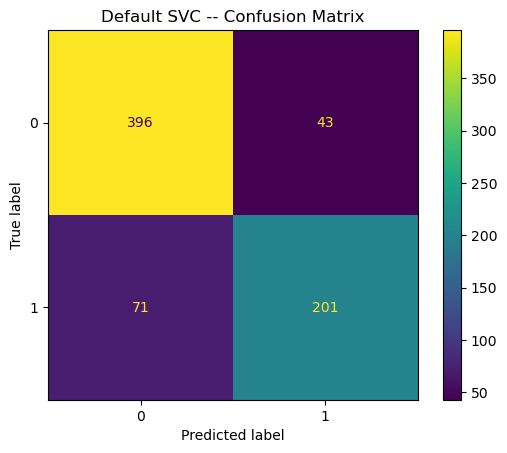

Default SVC -- Classification Report
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       439
           1       0.82      0.74      0.78       272

    accuracy                           0.84       711
   macro avg       0.84      0.82      0.83       711
weighted avg       0.84      0.84      0.84       711

Default SVC -- ROC-AUC Score: 0.8380


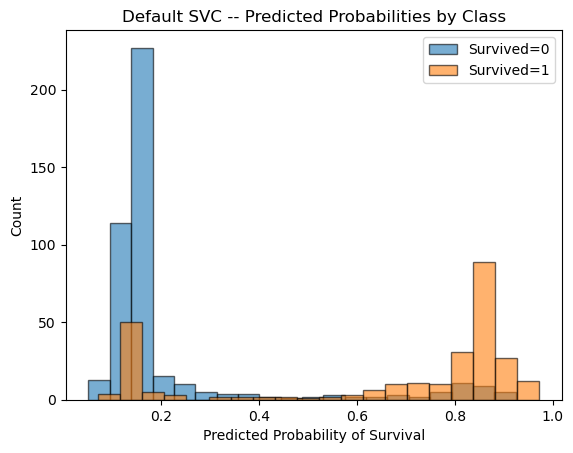

--------------------------


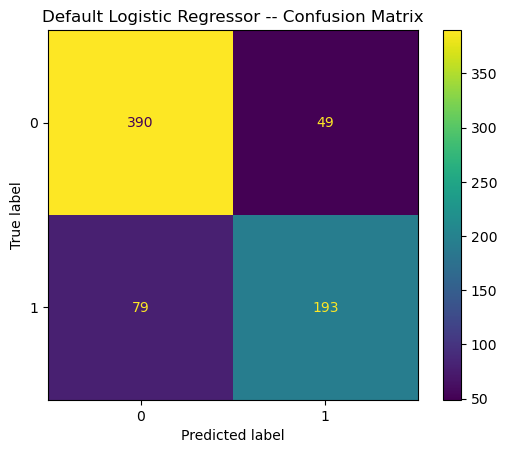

Default Logistic Regressor -- Classification Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       439
           1       0.80      0.71      0.75       272

    accuracy                           0.82       711
   macro avg       0.81      0.80      0.81       711
weighted avg       0.82      0.82      0.82       711

Default Logistic Regressor -- ROC-AUC Score: 0.8579


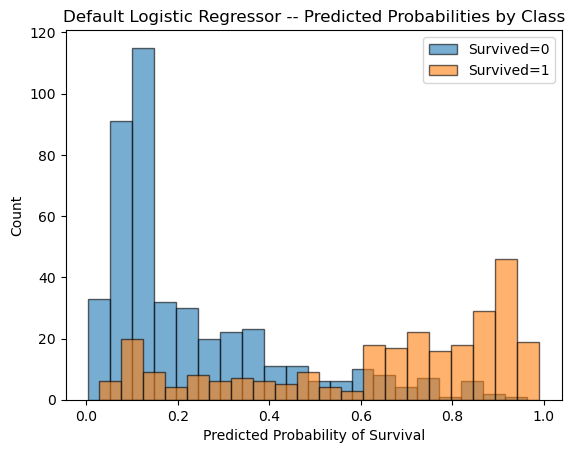

--------------------------


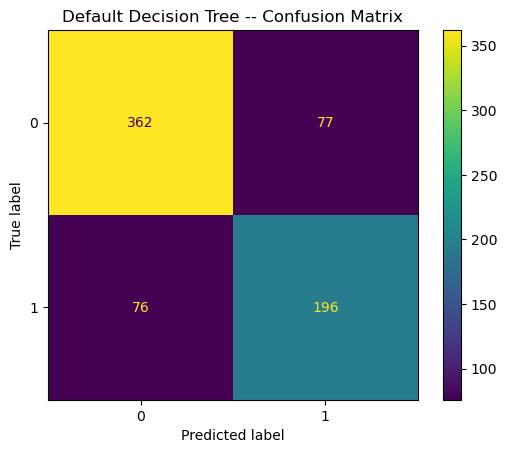

Default Decision Tree -- Classification Report
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       439
           1       0.72      0.72      0.72       272

    accuracy                           0.78       711
   macro avg       0.77      0.77      0.77       711
weighted avg       0.78      0.78      0.78       711

Default Decision Tree -- ROC-AUC Score: 0.7777


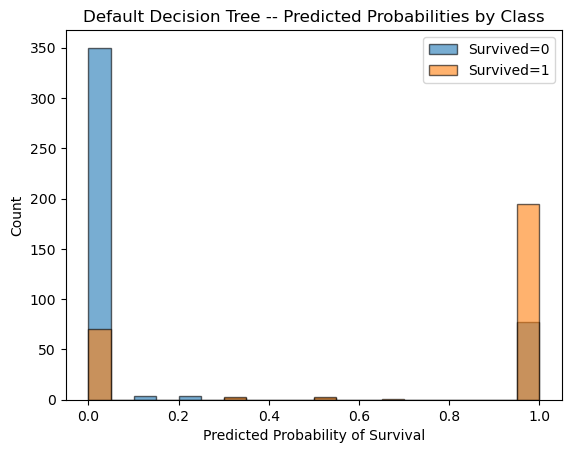

--------------------------


In [41]:
def evaluate_model(model_name, y_actual, y_preds, y_probs):
    '''Calculates and presents Confusion matrix, Classification report, ROC-AUC score, and probability plot'''
    
    # confusion matrix
    confus_matrix = confusion_matrix(y_actual, y_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=confus_matrix)
    disp.plot()
    plt.title(f'{model_name} -- Confusion Matrix')
    plt.show()

    # classification report
    print(f'{model_name} -- Classification Report')
    print(classification_report(y_actual, y_preds))

    # ROC-AUC
    roc = roc_auc_score(y_actual, y_probs[:, 1])
    print(f'{model_name} -- ROC-AUC Score: {roc:.4f}')

    # probability plot 
    fig, ax = plt.subplots()
    for label in [0, 1]:
        ax.hist(y_probs[y_actual == label, 1], bins=20, edgecolor='black', alpha=0.6, label=f'Survived={label}')
    ax.set_xlabel('Predicted Probability of Survival')
    ax.set_ylabel('Count')
    ax.set_title(f'{model_name} -- Predicted Probabilities by Class')
    ax.legend()
    plt.show()  

    print(f'--------------------------')

evaluate_model('Default SVC', y_train, svc_default_preds, svc_default_probs)
evaluate_model('Default Logistic Regressor', y_train, log_regressor_default_preds, log_regressor_default_probs)
evaluate_model('Default Decision Tree', y_train, decision_tree_default_preds, decision_tree_default_probs)

## Part 3(d) - Metric Breakdown

### Confusion Matrices

svc_default : [396 43]
              [71 201]

logistic_regressor_default : [390 49]
                             [79 193]          

decision_tree_default : [362 77]
                        [76 196]

Each confusion matrix was built with a decision threshold of 0.5. After initially training the models and calculating the metrics without any additional tuning, we see that the default SVC had the fewest false positives (FP) and false negatives (FNs), followed by the default logistic regressor, and then the default decision tree. Thus, implementation of the SVM clearly resulted in the optimal precision and recall scores. This is also supported by the raw metrics between the classification reports. 

### Classification Reports

Precision : Of all the predicted survivors, how many passengers were actually survivors.
Recall aka TPR : Of all the actual survivors, how many passengers were correctly identified as survivors.  


classification_reports = [{ 
    svc_default : {precision: {class_0: 0.85, class_1: 0.82}, recall: {class_0: 0.90, class_1: 0.74}, f1_score: {class_0: 0.87, class_1: 0.78}},
    logistic_regressor_default : {precision: {class_0: 0.83, class_1: 0.80}, recall: {class_0: 0.89, class_1: 0.71}, f1_score: {class_0: 0.86, class_1: 0.75}},
    decision_tree_default : {precision: {class_0: 0.83, class_1: 0.72}, recall: {class_0: 0.82, class_1: 0.72}, f1_score: {class_0: 0.83, class_1: 0.72}
    }]

While the confusion matrices provide a general overview of the models' performances, the classification reports give explicit insight into the data. The superior performance of the SVM is likely linked to its more flexible functionality.

Though the single default Decision Tree--which was not tuned with specific parameters (e.g., 'min_leaf' or 'max_depth')--might optimize the ingestion of, and fitting to, the data, this renders the single default DecisionTree susceptible to overfitting and subsequently less scalable. Further, the default Logistic Regressor at this stage was also not tuned with an optimal C, which likely hinders its learning rate. By contrast, the SVC supports the non-linearity of the data in that it can project the data into higher-dimensions and find the optimal hyperplane that creates the widest margin, all without needing as many parameters.

The Decision Tree had the lowest metrics overall. Given that the default DecisionTree was unconstrained and likely overfit as a result, the lower accuracy, precision, and recall are likely an indication that it was directly penalized by the cross-validation.


### ROC-AUC Scores

roc_auc_scores = [{
    svc_default : 0.8387
    logistic_regressor_default : 0.8579
    decision_tree_default : 0.7777
}]

Interestingly enough, each classifier had an roc_auc score above 0.5, though the logistic regressor had the highest. Despite having the highest roc_auc score, the metrics indicate that the logistic regressor was only slightly less efficient in classifying the mortalities (class 0) than the SVC, though it struggled the most out of the three models in correctly identifying the actual survivors. 

### Histograms

As indicated by its confusion matrix scores, the Logistic regressor had the most overlap as far as False Positives and False Negatives. This explains the obscurity of its histogram in comparison to that of the SVM and DecisionTree. Overall, the DecisionTree has a clear separation of the True Positives from the False Negatives, with minimal overlap reflected in its histogram. Similarly, the SVC histogram shows more distinct class separation, though there is visibly more overlap (indicative of FPs and FNs).

## Part 4 - Tuning Model Hyperparameters

In [42]:
%%time

svc_param_grid = {'kernel':['rbf'], # radial basis function
                'C':np.logspace(start= np.log10(0.001), stop= np.log10(100), num= 50), # regularization parameter
                'gamma':np.logspace(start= np.log10(0.001), stop= np.log10(10), num= 50)} # kernel coefficient for 'rbf', 'poly' and 'sigmoid'

log_regress_param_grid = {
    'penalty': ['l1', 'l2'], # regularization methods
    'C': np.logspace(-3, 3, 50), # regularization strengths
    'solver': ['liblinear'] # solver that accommodates l1 and l2  
    }      

decision_tree_param_grid = {
    'max_depth': np.arange(1, 21),
    'min_samples_leaf': np.arange(1, 21)
}
        
def tuning_model_hyperparameters(estimator, param_grid, x, y, label, scoring='accuracy', n_jobs= -1):
   '''Identifies optimal hyperparameters, employs exhaustive search of kernels, 
   kernel coefficients, and regularization strengths, presents optimal hyperparameters settings and scores'''

   grid_search_metrics = []

   grid_search = GridSearchCV(estimator=estimator,
                                param_grid=param_grid, 
                                scoring=scoring,
                                n_jobs=n_jobs,
                                cv=5)

   grid_search.fit(X=x, y=y)

   best_params = grid_search.best_params_
   best_score = grid_search.best_score_
   best_estimator = grid_search.best_estimator_

   grid_search_metrics.append({
       'Algorithm':label,
       'Optimal Params':best_params,
       'Best estimator': best_estimator,
       'Best score':best_score
   })

   grid_search_metrics_df = pd.DataFrame(grid_search_metrics)
   display(grid_search_metrics_df)

   return grid_search

svc_grid_search = tuning_model_hyperparameters(svc_default, svc_param_grid, X_train_oheenc, y_train, 'SVC RBF Tuned')

,Algorithm,Optimal Params,Best estimator,Best score
0,SVC RBF Tuned,"{'C': 49.417133613238384, 'gamma': 0.029470517...","SVC(C=np.float64(49.417133613238384), gamma=np...",0.848104


CPU times: total: 11.6 s
Wall time: 1min 21s


## Part 4(b) - Identifying the optimal hyperparameter settings for the Logistic Regressor

In [43]:
log_regress_grid_search = tuning_model_hyperparameters(log_regressor_default, log_regress_param_grid, X_train_oheenc, y_train, 'Log Regressor Liblinear Tuned')

,Algorithm,Optimal Params,Best estimator,Best score
0,Log Regressor Liblinear Tuned,"{'C': 0.09102981779915217, 'penalty': 'l2', 's...",LogisticRegression(C=np.float64(0.091029817799...,0.825638


## Part 4(c) - Identifying the optimal hyperparameter settings for the Decision Tree

In [44]:
decision_tree_grid_search = tuning_model_hyperparameters(decision_tree_default, decision_tree_param_grid, X_train_oheenc, y_train, 'DecisionTree Max_Depth_Min_Samples_Leaf Tuned')

,Algorithm,Optimal Params,Best estimator,Best score
0,DecisionTree Max_Depth_Min_Samples_Leaf Tuned,"{'max_depth': 5, 'min_samples_leaf': 3}","DecisionTreeClassifier(max_depth=np.int64(5), ...",0.839643


# Part 5 - Model Selection

## Part 5(a) - Accuracy Score Evaluation

Implementation of the GridSearchCV for each model revealed the tuned SVC to be the optimal model, with an accuracy score of ~84.8%. 

## Part 5(b) - Calculating label and probability predictions for each tuned classifier

In [45]:
# Tuned SVC
svc_tuned_preds = cross_val_predict(svc_grid_search.best_estimator_, X_train_oheenc, y_train, cv=5)
svc_tuned_probs = cross_val_predict(svc_grid_search.best_estimator_, X_train_oheenc, y_train, cv=5, method='predict_proba')

# tuned logistic regressor
log_regressor_tuned_preds = cross_val_predict(log_regress_grid_search.best_estimator_, X_train_oheenc, y_train, cv=5)
log_regressor_tuned_probs = cross_val_predict(log_regress_grid_search.best_estimator_, X_train_oheenc, y_train, cv=5, method='predict_proba')

# tuned decisiontree
decision_tree_tuned_preds = cross_val_predict(decision_tree_grid_search.best_estimator_, X_train_oheenc, y_train, cv=5) 
decision_tree_tuned_probs = cross_val_predict(decision_tree_grid_search.best_estimator_, X_train_oheenc, y_train, cv=5, method='predict_proba')

tuned_model_predictions = [svc_tuned_preds, svc_tuned_probs, log_regressor_tuned_preds, log_regressor_tuned_probs, decision_tree_tuned_preds, decision_tree_tuned_probs]

## Part 5(c) - Calculating and Presenting the Confusion Matrix, the Classification Report, the ROC-AUC Score, and the Plot of Predicted Probabilities by Target Class Label [Tuned Classifiers]

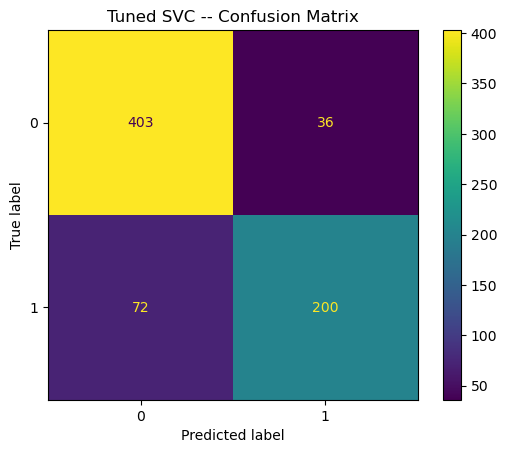

Tuned SVC -- Classification Report
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       439
           1       0.85      0.74      0.79       272

    accuracy                           0.85       711
   macro avg       0.85      0.83      0.83       711
weighted avg       0.85      0.85      0.85       711

Tuned SVC -- ROC-AUC Score: 0.8521


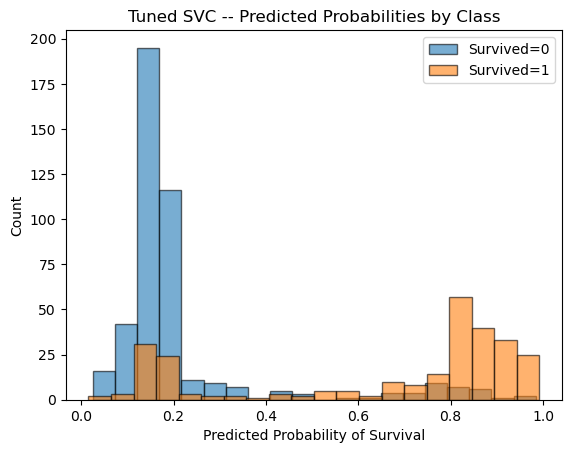

--------------------------


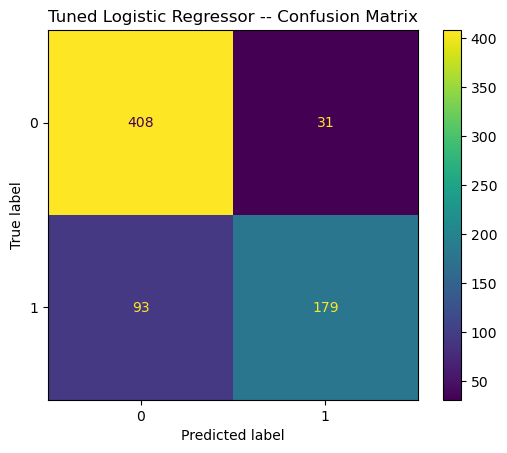

Tuned Logistic Regressor -- Classification Report
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       439
           1       0.85      0.66      0.74       272

    accuracy                           0.83       711
   macro avg       0.83      0.79      0.81       711
weighted avg       0.83      0.83      0.82       711

Tuned Logistic Regressor -- ROC-AUC Score: 0.8507


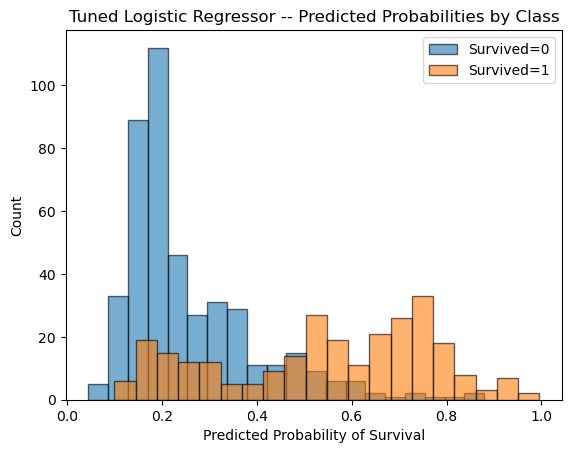

--------------------------


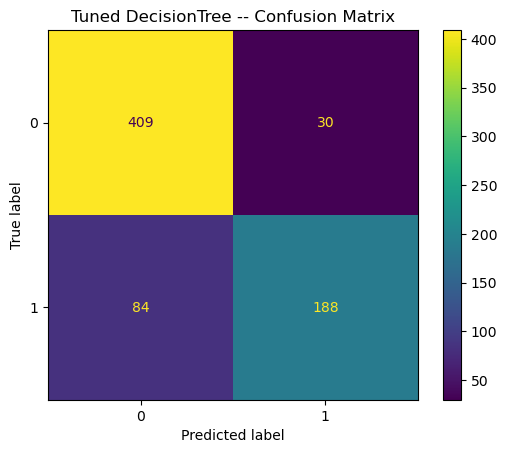

Tuned DecisionTree -- Classification Report
              precision    recall  f1-score   support

           0       0.83      0.93      0.88       439
           1       0.86      0.69      0.77       272

    accuracy                           0.84       711
   macro avg       0.85      0.81      0.82       711
weighted avg       0.84      0.84      0.84       711

Tuned DecisionTree -- ROC-AUC Score: 0.8581


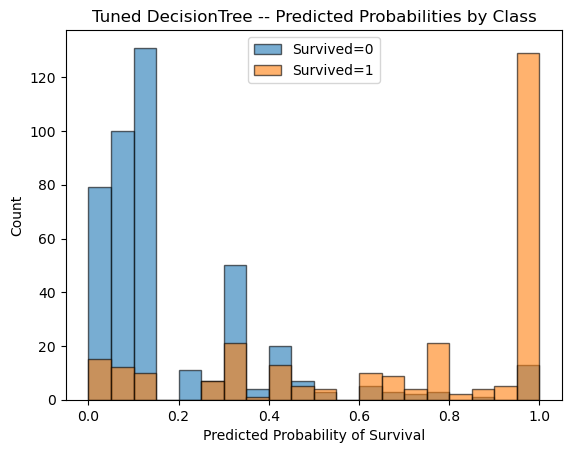

--------------------------


In [46]:
evaluate_model('Tuned SVC', y_train, svc_tuned_preds, svc_tuned_probs)
evaluate_model('Tuned Logistic Regressor', y_train, log_regressor_tuned_preds, log_regressor_tuned_probs)
evaluate_model('Tuned DecisionTree', y_train, decision_tree_tuned_preds, decision_tree_tuned_probs)

## Part 5(d) - Model Breakdown

## Confusion Matrices

svc_default : [396 43]
              [71 201]

logistic_regressor_default : [390 49]
                             [79 193]          

decision_tree_default : [362 77]
                        [76 196]
___________
                                       
svc_tuned : [403 36]
              [72 200]

logistic_regressor_tuned : [408 31]
                             [93 179]      

decision_tree_tuned : [409 30]
                        [84 188]
___________

A comparison of each model's confusion matrices (default vs. tuned) showed that tuning the classifiers resulted in fewer False Positives (FPs) and (FNs), and thus, better accuracy in distinguishing the True Positives (TPs) from the True Negatives (TNs). With respect to the class imbalance in this dataset, each tuned model identified more TNs and fewer TPs; however, the tuned Decision Tree identified the highest quantity of TNs, followed by the tuned logistic regressor, and then the tuned SVC. By contrast, the tuned SVC identified the highest number of TPs, followed by the DecisionTree, and then the Logistic Regressor. With regard to the False Positive Rate, the tuned SVC reported the highest quantity of FPs and the lowest number of FNs; the logistic regressor reported the highest number of FNs, but held the middle-ground with reported FPs; whereas, the DecisionTree held the middle-ground with FNs while reporting the fewest FPs.

## Classification Reports

Precision : Of all the predicted survivors, how many passengers were actually survivors.
Recall aka TPR : Of all the actual survivors, how many passengers were correctly identified as survivors.  

classification_reports = { 
    svc_default : {precision: {class_0: 0.85, class_1: 0.82}, recall: {class_0: 0.90, class_1: 0.74}, f1_score: {class_0: 0.87, class_1: 0.78}},
    logistic_regressor_default : {precision: {class_0: 0.83, class_1: 0.80}, recall: {class_0: 0.89, class_1: 0.71}, f1_score: {class_0: 0.86, class_1: 0.75}},
    decision_tree_default : {precision: {class_0: 0.83, class_1: 0.72}, recall: {class_0: 0.82, class_1: 0.72}, f1_score: {class_0: 0.83, class_1: 0.72}
    }
___________    

tuned_classification_reports = { 
    svc_tuned : {precision: {class_0: 0.85, class_1: 0.85}, recall: {class_0: 0.92, class_1: 0.74}, f1_score: {class_0: 0.88, class_1: 0.79}},
    logistic_regressor_tuned : {precision: {class_0: 0.81, class_1: 0.85}, recall: {class_0: 0.93, class_1: 0.66}, f1_score: {class_0: 0.87, class_1: 0.74}},
    decision_tree_tuned : {precision: {class_0: 0.83, class_1: 0.86}, recall: {class_0: 0.93, class_1: 0.69}, f1_score: {class_0: 0.88, class_1: 0.77}
    }

Tuning the models resulted in higher precision with respect to distinctions of 'survived' passengers (i.e., class_1); however, tuning both the SVC and DecisionTree showed no effect to their precision scores with respect to distinction of mortalities (i.e., class_0). The logistic regressor was the only model to report a lower (class_0) precision score after tuning.

With respect to the True Positive Rates, aka Recall, tuning each model resulted in higher recall rates for class_0 (recall >= 0.92); however, the SVC was the only model to report the same class_1 recall pre/post-tuning. Both the logistic regressor and the DecisionTree showed a decline in class_1 recall after tuning. 

Evaluation of the f1 scores for each model showed that tuning resulted in an overall score-increase for both the SVC and the Decision Tree. However, the logistic regressor only improved its class_0 f1 score after tuning; its class_1 f1 score actually decreased slightly.


# ROC-AUC Score

default_roc_auc_scores = {
    svc_default : 0.8380
    logistic_regressor_default : 0.8579
    decision_tree_default : 0.7777
}
___________

tuned_roc_auc_scores = {
    svc_tuned : 0.8521
    logistic_regressor_tuned : 0.8507
    decision_tree_tuned : 0.8581
}
___________

Overall, we see that tuning the models resulted in an roc-auc score-increase for both the SVC and the DecisionTree, with a minimal decrease for the logistic regressor. The tuned DecisionTree had the highest roc_auc score of 0.8581.

### Summary

Each model required a different tuning strategy. For the SVC, the initial C search range ended at np.log10(10), but the optimal value landed near the boundary at ~6.87--a boundary result signals that the true optimum may lie outside the searched range. Extending the upper bound to np.log10(100) found C=~49.4, a more credible value well within the new range. I also set a random_state for the SVC so I could have reproducibility, as re-running the kernels kept changing the SVC ROC-AUC score. Though this did not affect the performance hierarchy, it did indeed affect consistency metrics that others would assess when running the code.   

For the Logistic Regressor, the optimal configuration was L2 penalty with C=0.091, confirming that moderate regularization--shrinking coefficients without eliminating them--was preferred over the more aggressive L1 solution. For the Decision Tree, max_depth=5 and min_samples_leaf=3 produced the best-performing tree (best score: ~83.9%). These hyperparameters enabled the tree to be shallow enough to avoid overfitting while maintaining the depth necessary to capture the non-linear survival patterns.

Across all metrics, the **tuned SVC is the champion model**. It achieved the highest GridSearchCV accuracy (~84.8%), the best balance of precision and recall across both classes, and a competitive ROC-AUC (0.8521). The tuned Decision Tree earned the highest ROC-AUC (0.8581) with an accuracy score of (83.9%) and class_1 recall (0.69), meaning it misclassifies more actual survivors. The Logistic Regressor, while interpretable and computationally cheap, reported slightly lower scores in terms of accuracy (82.6%) and class_1 recall (0.66) — trading survivor detection for improved class_0 specificity after tuning.

Given the humanitarian context of survival classification — where a false negative means labeling a survivor as deceased and a false positive meaning a deceased person is still alive — the SVC's superior class_1 recall (0.74), its highest overall accuracy, and its moderate roc-auc score make it the recommended model for deployment on the held-out test set.